**Implementación de modelos supervisados (regresión) con Scikit-learn.**

### Importe de librerías necesarias


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocesamiento.data_preprocessing import corregir_valores_negativos
from preprocesamiento.data_preprocessing import detectar_inconsistencias
from preprocesamiento.data_preprocessing import separar_objetivo_features
from preprocesamiento.data_preprocessing import eliminar_nulos_objetivo
from preprocesamiento.pipelines import aplicar_pipeline_limpieza
from preprocesamiento.pipelines import build_cleaning_pipeline_reg
from preprocesamiento.pipelines import build_decision_tree_regressor_pipeline
from preprocesamiento.pipelines import build_linear_regression_pipeline
from preprocesamiento.pipelines import build_preprocessor
from model_evaluation import evaluar_regresor
from model_training import entrenar_modelo

### Carga de Datos

In [3]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes.csv"
data = pd.read_csv(url)

### Preprocesamiento de datos

#### Detección de inconsistencias

In [4]:
# Detección de inconsistencias: negativos o ceros en columnas que deberían ser positivas.
conteo_negativos, conteo_ceros = detectar_inconsistencias(data)

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [5]:
# Tratamiento: corrige valores negativos convirtiéndolos a valor absoluto.
data = corregir_valores_negativos(data)

Valores negativos corregidos a valores absolutos en las columnas relevantes.


# 1. Modelamiento para variable objetivo "deuda_total"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [6]:
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data,
    target="deuda_total",
 )

## Construcción de arrays para procesamiento

In [7]:
numerical_features = ["gasto_mensual", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [8]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression

### Pipeline para Regresión Lineal

In [9]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [10]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="deuda_total")
data_transformada.head()

,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,deuda_total
0,0.928655,-1.481935,0.219473,0.979150,1.193186,-0.724598,1.653219,0.002765,1.535116,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.448145e+06
1,-0.634528,-0.260058,1.323554,0.139166,0.140295,-0.358339,1.186639,0.711810,-0.205888,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.620569e+06
2,-0.091194,1.738263,0.000000,-0.028831,-1.731512,0.374180,0.472486,0.711810,-0.786223,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,5.395040e+06
3,0.133315,-1.611474,-0.949411,0.307163,-1.643771,-1.273987,-0.165490,-0.706279,0.664614,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.999350e+06
4,0.681864,-1.351398,-0.220475,-0.980813,-1.351302,-0.907728,0.958110,0.002765,-0.496056,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.637711e+06


In [11]:
target = "deuda_total"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "num_productos", 
    "dia_semana_registro_Lunes", 
    "hora_registro",
    "dia_semana_registro_Viernes",
    "dia_semana_registro_Jueves",
    "genero_Masculino"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento


In [13]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [14]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 678,214


In [15]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [16]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=7):
- abandono_0
- num_productos
- dia_semana_registro_Lunes
- hora_registro
- dia_semana_registro_Viernes
- dia_semana_registro_Jueves
- genero_Masculino


## Modelo DecisionTreeRegressor

### Pipeline para DecisionTreeRegressor

In [17]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [18]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="deuda_total")
data_transformada.head()

,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,deuda_total
0,0.928655,-1.481935,0.219473,0.979150,1.193186,-0.724598,1.653219,0.002765,1.535116,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.448145e+06
1,-0.634528,-0.260058,1.323554,0.139166,0.140295,-0.358339,1.186639,0.711810,-0.205888,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.620569e+06
2,-0.091194,1.738263,0.000000,-0.028831,-1.731512,0.374180,0.472486,0.711810,-0.786223,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,5.395040e+06
3,0.133315,-1.611474,-0.949411,0.307163,-1.643771,-1.273987,-0.165490,-0.706279,0.664614,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.999350e+06
4,0.681864,-1.351398,-0.220475,-0.980813,-1.351302,-0.907728,0.958110,0.002765,-0.496056,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.637711e+06


In [19]:
target = "deuda_total"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "num_productos", 
    "dia_semana_registro_Lunes", 
    "hora_registro",
    "dia_semana_registro_Viernes",
    "dia_semana_registro_Jueves",
    "genero_Masculino"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento

In [21]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [22]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.009
MAE   : 684,001


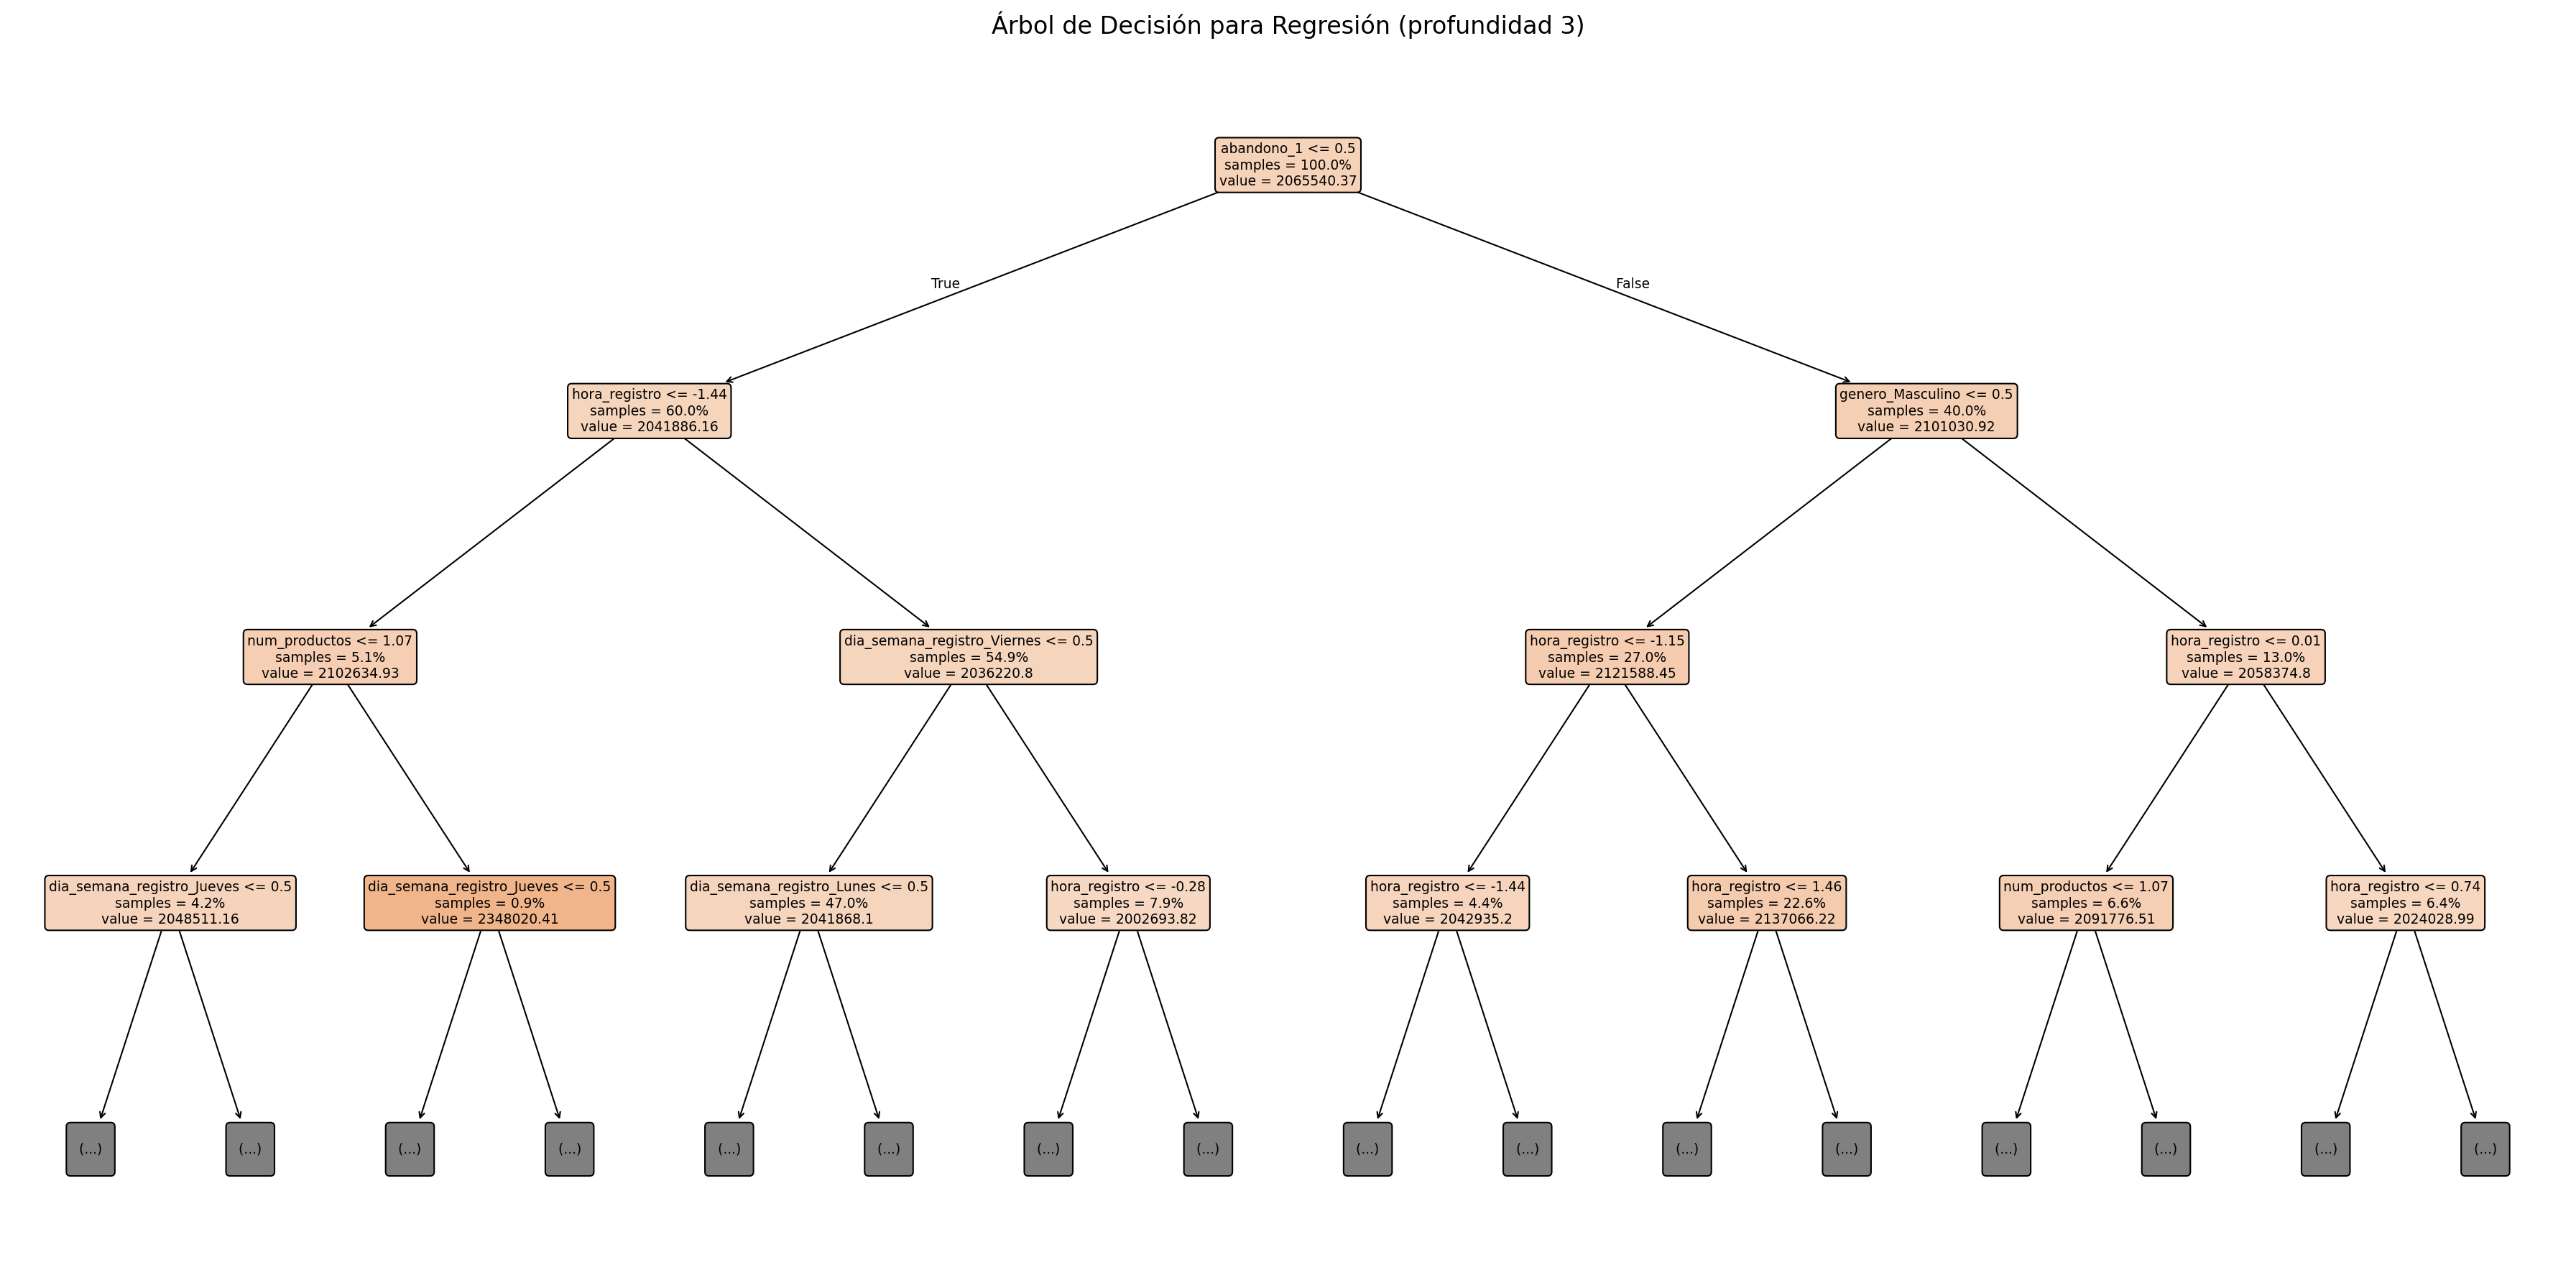

In [23]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 2. Modelamiento para variable objetivo "gasto_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [24]:
data_filtrada = eliminar_nulos_objetivo(data, target="gasto_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="gasto_mensual",
 )

In [25]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [26]:
numerical_features = ["deuda_total", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [27]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression

### Pipeline para Regresión Lineal

In [28]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [29]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="gasto_mensual")
data_transformada.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,gasto_mensual
0,0.569917,-1.486023,2.155785e-01,0.979649,1.189383,-0.724314,1.652380,0.003360,1.535248,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,524088.303055
1,-0.534765,-0.263573,1.313490e+00,0.140316,0.137993,-0.358080,1.185892,0.712696,-0.205725,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,314259.751474
2,1.849874,1.735685,2.776258e-16,-0.027551,-1.731144,0.374387,0.471879,0.712696,-0.786049,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,387192.316142
3,1.305687,-1.615623,-9.467730e-01,0.308182,-1.643529,-1.273665,-0.165972,-0.705976,0.664762,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,417328.601856
4,-0.511883,-1.355425,-2.219100e-01,-0.978795,-1.351476,-0.907431,0.957408,0.003360,-0.495887,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,490961.191253


In [30]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento


In [32]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [33]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 119,185


In [34]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [35]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=9):
- abandono_0
- tipo_plan
- dia_semana_registro_Viernes
- region_Norte
- canal_registro_App
- dia_semana_registro_Jueves
- uso_app
- estado_civil_Soltero
- region_Sur


## Modelo DecisionTreeRegressor

### Pipeline para DecisionTreeRegressor

In [36]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [37]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="gasto_mensual")
data_transformada.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,gasto_mensual
0,0.569917,-1.486023,2.155785e-01,0.979649,1.189383,-0.724314,1.652380,0.003360,1.535248,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,524088.303055
1,-0.534765,-0.263573,1.313490e+00,0.140316,0.137993,-0.358080,1.185892,0.712696,-0.205725,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,314259.751474
2,1.849874,1.735685,2.776258e-16,-0.027551,-1.731144,0.374387,0.471879,0.712696,-0.786049,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,387192.316142
3,1.305687,-1.615623,-9.467730e-01,0.308182,-1.643529,-1.273665,-0.165972,-0.705976,0.664762,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,417328.601856
4,-0.511883,-1.355425,-2.219100e-01,-0.978795,-1.351476,-0.907431,0.957408,0.003360,-0.495887,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,490961.191253


In [38]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento

In [40]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [41]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.015
MAE   : 120,487


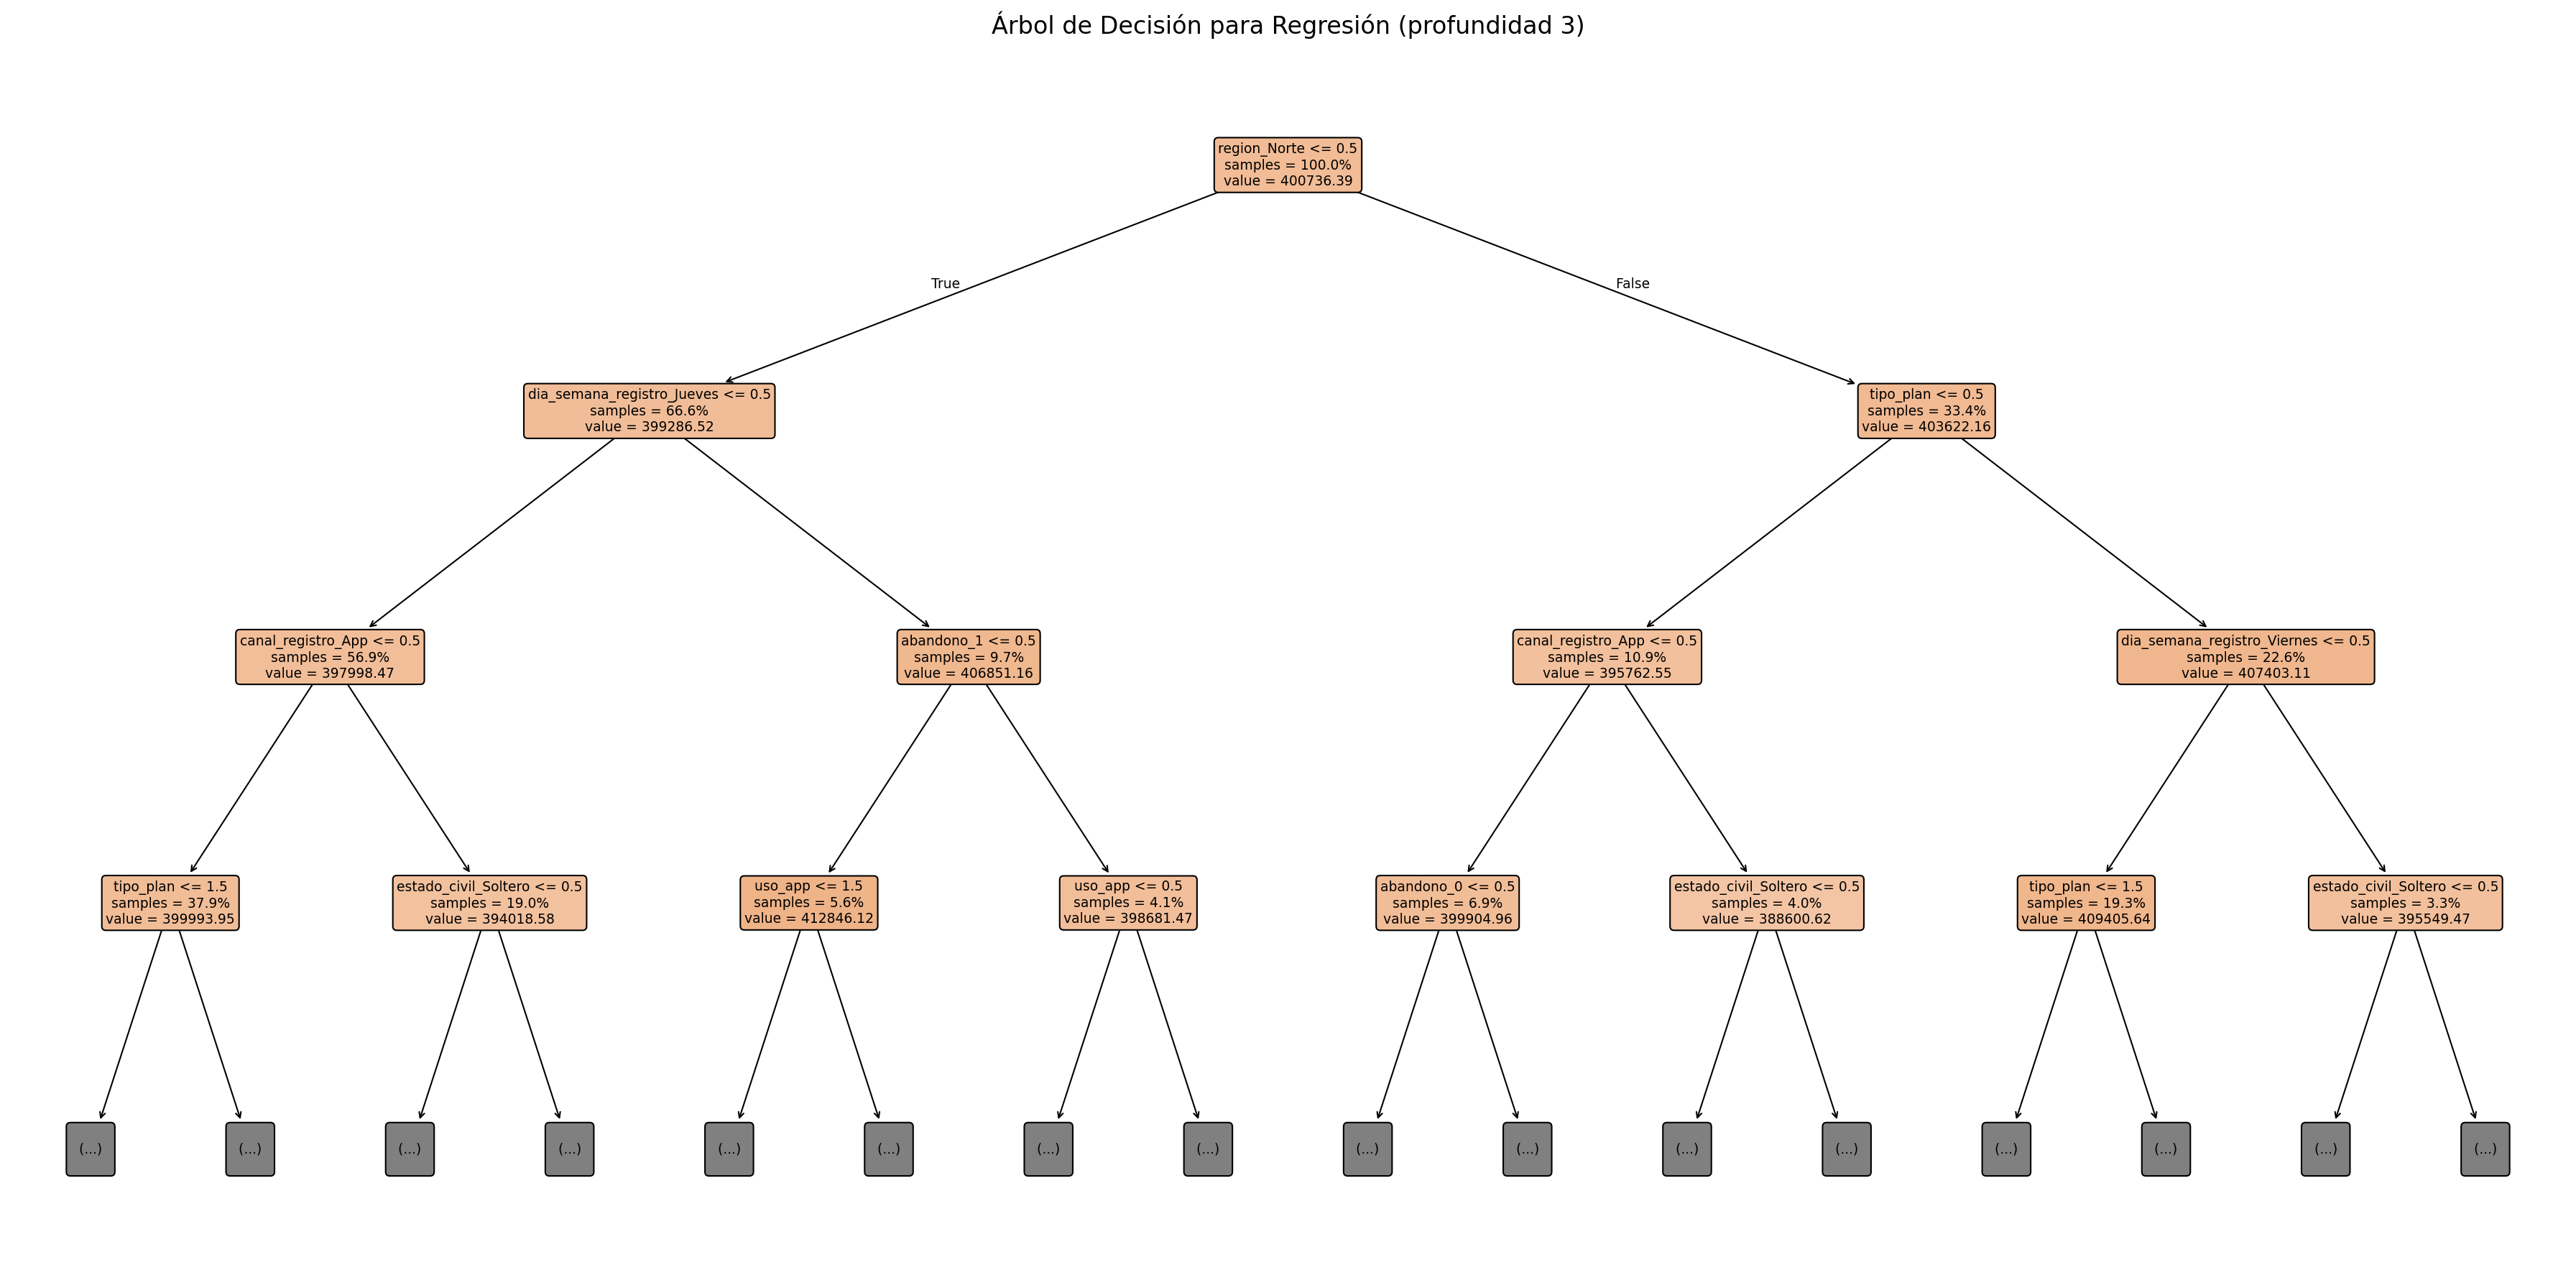

In [42]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 3. Modelamiento para variable objetivo "score_crediticio"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [43]:
data_filtrada = eliminar_nulos_objetivo(data, target="score_crediticio")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="score_crediticio",
 )

In [44]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [45]:
numerical_features = ["gasto_mensual", "deuda_total", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [46]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression

### Pipeline para Regresión Lineal

In [47]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [48]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="score_crediticio")
data_transformada.head()

,gasto_mensual,deuda_total,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,score_crediticio
0,0.925409,0.364037,0.215090,0.978690,1.194689,-0.725648,1.649868,0.004143,1.534779,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,455.406680
1,-0.634326,-0.426428,1.304595,0.138876,0.141754,-0.359689,1.183672,0.713265,-0.207794,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,575.048508
2,-0.092191,3.178788,0.000000,-0.029087,-1.730132,0.372228,0.470106,0.713265,-0.788652,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,770.716904
3,0.131824,0.890525,-0.938362,0.306839,-1.642387,-1.274586,-0.167345,-0.704979,0.663492,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,442.722671
4,0.679162,-0.410055,-0.219049,-0.980876,-1.349905,-0.908627,0.955331,0.004143,-0.498223,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,468.188403


In [49]:
target = "score_crediticio"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "hora_registro", 
    "frecuencia_compra", 
    "dia_semana_registro_Domingo",
    "ultima_compra_dias",
    "region_Sur",
    "region_Centro",
    "ingreso_mensual",
    "dia_semana_registro_Miercoles",
    "canal_registro_App",
    "edad"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento


In [51]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [52]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : 0.000
MAE   : 82


In [53]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [54]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=11):
- abandono_0
- hora_registro
- frecuencia_compra
- dia_semana_registro_Domingo
- ultima_compra_dias
- region_Sur
- region_Centro
- ingreso_mensual
- dia_semana_registro_Miercoles
- canal_registro_App
- edad


## Modelo DecisionTreeRegressor

### Pipeline para DecisionTreeRegressor

In [55]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [56]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="score_crediticio")
data_transformada.head()

,gasto_mensual,deuda_total,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,score_crediticio
0,0.925409,0.364037,0.215090,0.978690,1.194689,-0.725648,1.649868,0.004143,1.534779,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,455.406680
1,-0.634326,-0.426428,1.304595,0.138876,0.141754,-0.359689,1.183672,0.713265,-0.207794,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,575.048508
2,-0.092191,3.178788,0.000000,-0.029087,-1.730132,0.372228,0.470106,0.713265,-0.788652,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,770.716904
3,0.131824,0.890525,-0.938362,0.306839,-1.642387,-1.274586,-0.167345,-0.704979,0.663492,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,442.722671
4,0.679162,-0.410055,-0.219049,-0.980876,-1.349905,-0.908627,0.955331,0.004143,-0.498223,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,468.188403


In [57]:
target = "score_crediticio"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "hora_registro", 
    "frecuencia_compra", 
    "dia_semana_registro_Domingo",
    "ultima_compra_dias",
    "region_Sur",
    "region_Centro",
    "ingreso_mensual",
    "dia_semana_registro_Miercoles",
    "canal_registro_App",
    "edad"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento

In [59]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [60]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.035
MAE   : 83


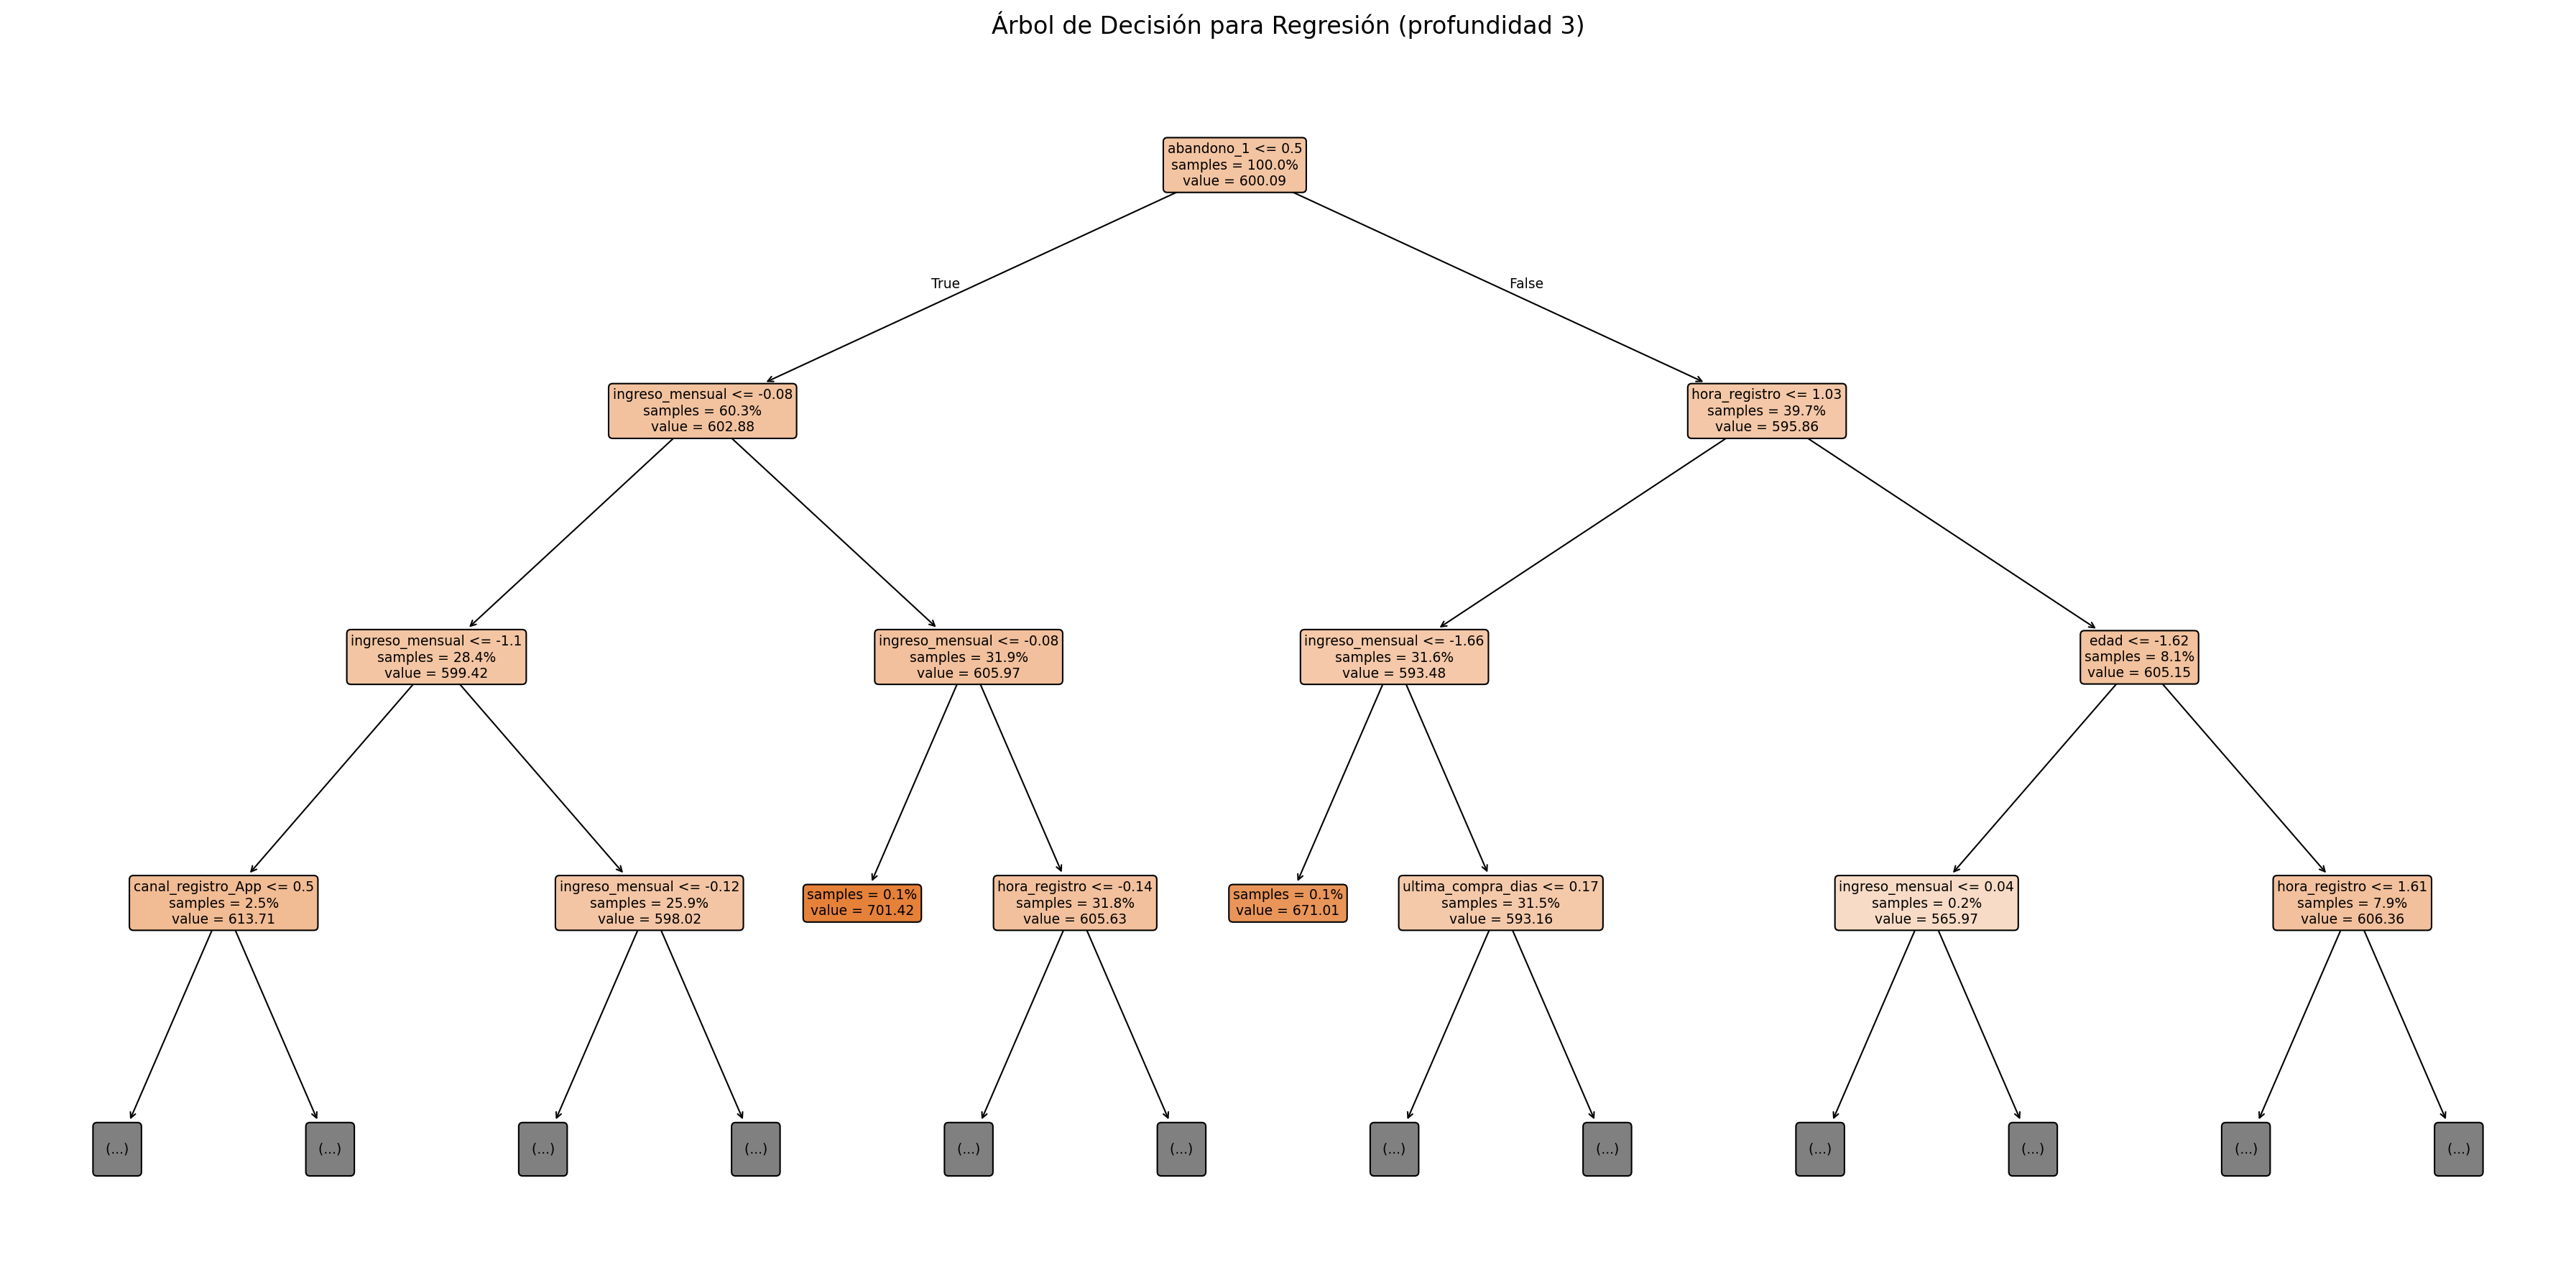

In [61]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 3. Modelamiento para variable objetivo "ingreso_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [62]:
data_filtrada = eliminar_nulos_objetivo(data, target="ingreso_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="ingreso_mensual",
 )

In [63]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [64]:
numerical_features = ["gasto_mensual", "deuda_total", "score_crediticio", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [65]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression

### Pipeline para Regresión Lineal

In [66]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [67]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="ingreso_mensual")
data_transformada.head()

,gasto_mensual,deuda_total,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,ingreso_mensual
0,0.929503,0.366899,-1.482183,0.978352,1.189188,-0.723407,1.652991,0.000635,1.535914,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.243057e+05
1,-0.634366,-0.425609,-0.259638,0.139164,0.137320,-0.357081,1.186471,0.709976,-0.204351,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.384687e+06
2,0.133814,0.894747,-1.611793,0.307002,-1.645014,-1.272897,-0.165485,-0.708706,0.665781,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.369032e+05
3,0.682604,-0.409193,-1.351575,-0.979754,-1.352828,-0.906571,0.957971,0.000635,-0.494396,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,7.408561e+05
4,1.856198,-0.226757,1.220284,1.537811,-0.563926,0.375571,1.062700,-0.708706,0.810803,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.247810e+05


In [68]:
target = "ingreso_mensual"
mejores_variables_predictoras = [
    "tiene_tarjeta_credito_1",
    "tiene_tarjeta_credito_0", 
    "dia_semana_registro_Viernes", 
    "estado_civil_Casado", 
    "score_crediticio",
    "region_Centro"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento


In [70]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [71]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.001
MAE   : 236,109


In [72]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- tiene_tarjeta_credito_0


In [73]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=5):
- tiene_tarjeta_credito_1
- dia_semana_registro_Viernes
- estado_civil_Casado
- score_crediticio
- region_Centro


## Modelo DecisionTreeRegressor

### Pipeline para DecisionTreeRegressor

In [74]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [75]:
# Aplica el pipeline de limpieza al dataset y obtiene el resultado transformado.
data_transformada = aplicar_pipeline_limpieza(pipeline_limpieza, var_indep, var_dep, target_col="ingreso_mensual")
data_transformada.head()

,gasto_mensual,deuda_total,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,ingreso_mensual
0,0.929503,0.366899,-1.482183,0.978352,1.189188,-0.723407,1.652991,0.000635,1.535914,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.243057e+05
1,-0.634366,-0.425609,-0.259638,0.139164,0.137320,-0.357081,1.186471,0.709976,-0.204351,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.384687e+06
2,0.133814,0.894747,-1.611793,0.307002,-1.645014,-1.272897,-0.165485,-0.708706,0.665781,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.369032e+05
3,0.682604,-0.409193,-1.351575,-0.979754,-1.352828,-0.906571,0.957971,0.000635,-0.494396,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,7.408561e+05
4,1.856198,-0.226757,1.220284,1.537811,-0.563926,0.375571,1.062700,-0.708706,0.810803,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.247810e+05


In [76]:
target = "ingreso_mensual"
mejores_variables_predictoras = [
    "tiene_tarjeta_credito_1",
    "tiene_tarjeta_credito_0", 
    "dia_semana_registro_Viernes", 
    "estado_civil_Casado", 
    "score_crediticio",
    "region_Centro"
]
X = data_transformada[mejores_variables_predictoras]
y = data_transformada[target]

### División train/test


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

### Entrenamiento

In [78]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [79]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.021
MAE   : 240,849


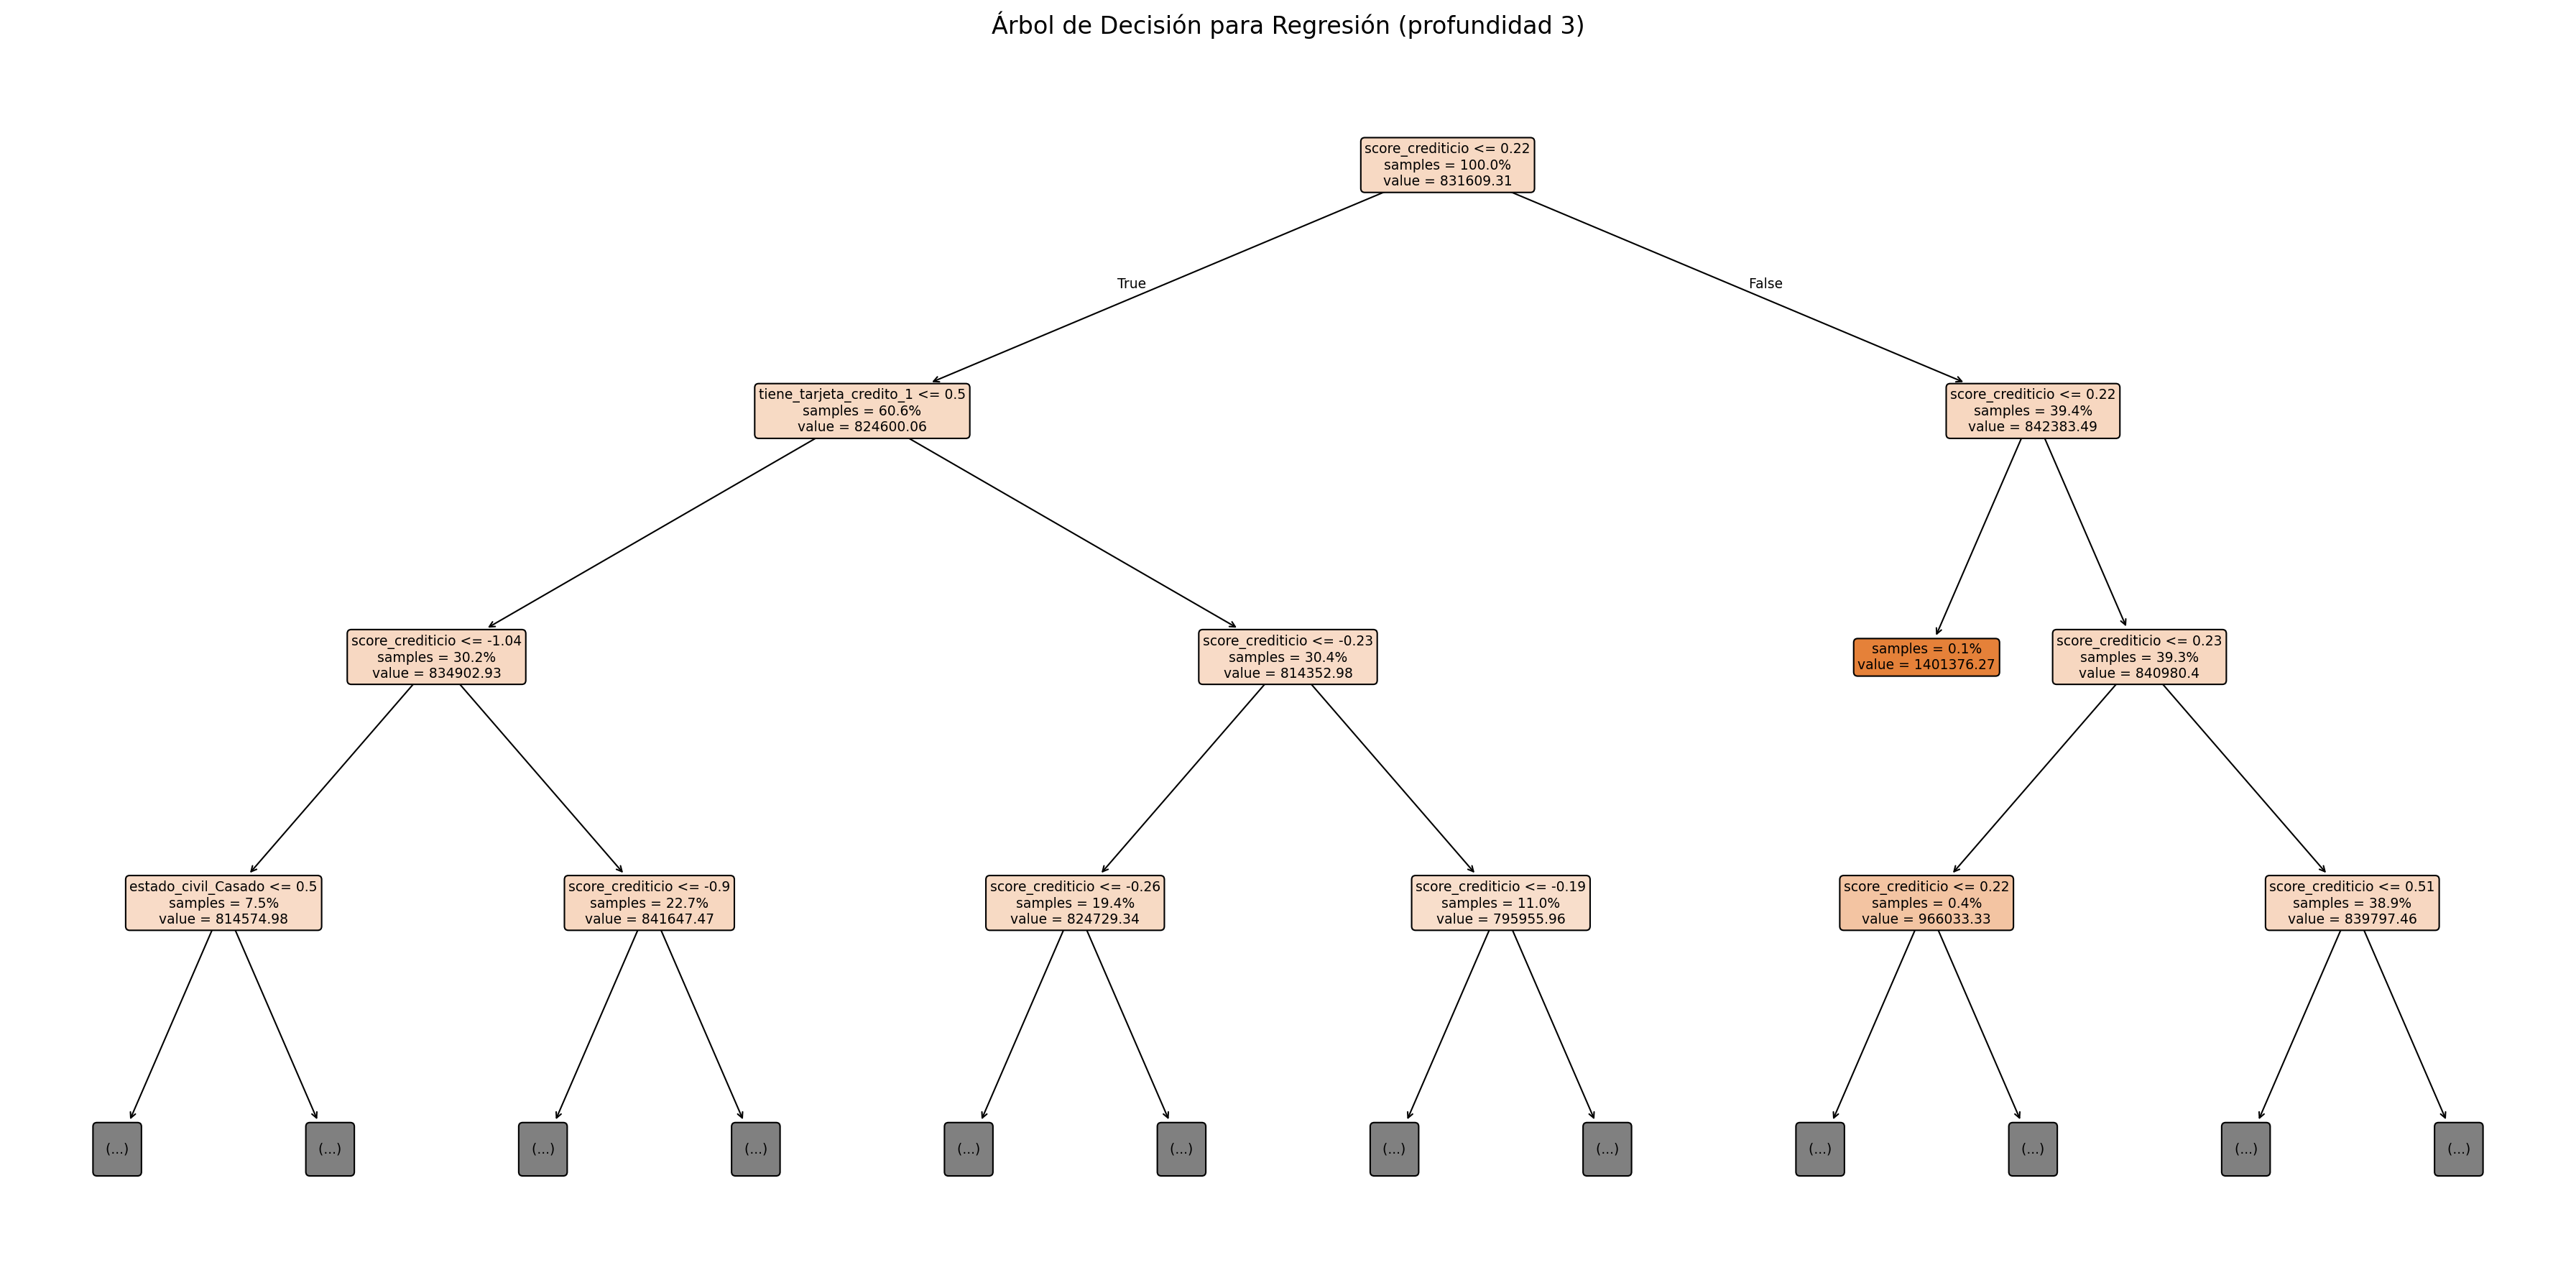

In [80]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()